# Ship Detection in Satellite Images with YOLO11 - v32 Runs

## Practical Work — AI Diploma: Computer Vision

---

Fine-tune YOLO11 to detect **ships** in **satellite images**, running entirely in a local Python environment.

### Pipeline
```
Kaggle Dataset        Roboflow             YOLO11 Training       Deploy
(Satellite images) -> (Ship annotation) -> (Fine-tuning)      -> (API)
```

## Prerequisites

1. Install dependencies: `uv sync`
2. Create a `.env` file in the project root with the following keys:
   ```
   ROBOFLOW_API_KEY=your_roboflow_key
   KAGGLE_USERNAME=your_kaggle_username
   KAGGLE_KEY=your_kaggle_api_key
   ```
   - Roboflow key: https://app.roboflow.com/settings/api
   - Kaggle key: https://kaggle.com/settings → API → Create New Token

---
## Section 0: Environment Setup

In [1]:
!nvidia-smi

Mon Jun  1 18:34:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 573.91                 Driver Version: 573.91         CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                  Driver-Model | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX A4000 Laptop GPU  WDDM  |   00000000:01:00.0  On |                  N/A |
| N/A   53C    P8             16W /  100W |     918MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
import random
from pathlib import Path

import numpy as np
import torch
import ultralytics
from IPython.display import Image as IPyImage, display

ROOT = Path.cwd()
DATASETS_DIR = ROOT / "datasets"
RUNS_DIR = ROOT / "runs"
MODELS_DIR = ROOT / "models"
KAGGLE_DIR = DATASETS_DIR / "ships_satellite"
KAGGLE_DATASET = "rhammell/ships-in-satellite-imagery"
MODEL_NAME = "yolo11m.pt"

DATASETS_DIR.mkdir(exist_ok=True)
KAGGLE_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Project root : {ROOT}")
print(f"PyTorch      : {torch.__version__}")
print(f"Device       : {device}")
ultralytics.checks()

Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
Setup complete  (12 CPUs, 63.7 GB RAM, 837.6/952.6 GB disk)


In [3]:
torch.cuda.is_available()

True

In [4]:
from dotenv import load_dotenv

load_dotenv()

ROBOFLOW_API_KEY = os.getenv("ROBOFLOW_API_KEY")
KAGGLE_USERNAME = os.getenv("KAGGLE_USERNAME")
KAGGLE_KEY = os.getenv("KAGGLE_KEY")

missing = [
    k
    for k, v in {
        "ROBOFLOW_API_KEY": ROBOFLOW_API_KEY,
        "KAGGLE_USERNAME": KAGGLE_USERNAME,
        "KAGGLE_KEY": KAGGLE_KEY,
    }.items()
    if not v
]

if missing:
    raise ValueError(f"Missing keys in .env: {', '.join(missing)}")

# Write kaggle.json expected by the kaggle CLI
kaggle_config_dir = Path.home() / ".kaggle"
kaggle_config_dir.mkdir(exist_ok=True)
kaggle_json = kaggle_config_dir / "kaggle.json"
kaggle_json.write_text(f'{{"username":"{KAGGLE_USERNAME}","key":"{KAGGLE_KEY}"}}')
kaggle_json.chmod(0o600)

print("Secrets loaded successfully.")

Secrets loaded successfully.


---
## Section 1: Kaggle Dataset Download

The **Satellite Images of Water Bodies** dataset (franciscoescobar) contains ~2,800 satellite images
organised in four categories: `sea`, `lake`, `river`, `swamp`.

We focus on `sea` images, which have the highest likelihood of containing ships.

In [5]:
import kaggle

# The kaggle API unzips into a subfolder that mirrors the zip structure:
# KAGGLE_DIR / "shipsnet" / "shipsnet" / *.png
SHIPSNET_DIR = KAGGLE_DIR / "shipsnet" / "shipsnet"

if SHIPSNET_DIR.exists() and any(SHIPSNET_DIR.iterdir()):
    print("Dataset already present — skipping download.")
else:
    print("Downloading dataset from Kaggle...")
    kaggle.api.dataset_download_files(
        KAGGLE_DATASET,
        path=str(KAGGLE_DIR),
        unzip=True,
    )
    print("Download complete.")

ship_images = list(SHIPSNET_DIR.glob("1__*.png"))
nonship_images = list(SHIPSNET_DIR.glob("0__*.png"))

print(f"\nshipsnet directory : {SHIPSNET_DIR}")
print(f"  ship chips       : {len(ship_images)}")
print(f"  non-ship chips   : {len(nonship_images)}")
print(f"  total            : {len(ship_images) + len(nonship_images)}")

Dataset already present — skipping download.

shipsnet directory : c:\Users\leona\source\repos\diplo-mod-2\datasets\ships_satellite\shipsnet\shipsnet
  ship chips       : 1000
  non-ship chips   : 3000
  total            : 4000


Ship chips     : 1000
Non-ship chips : 3000


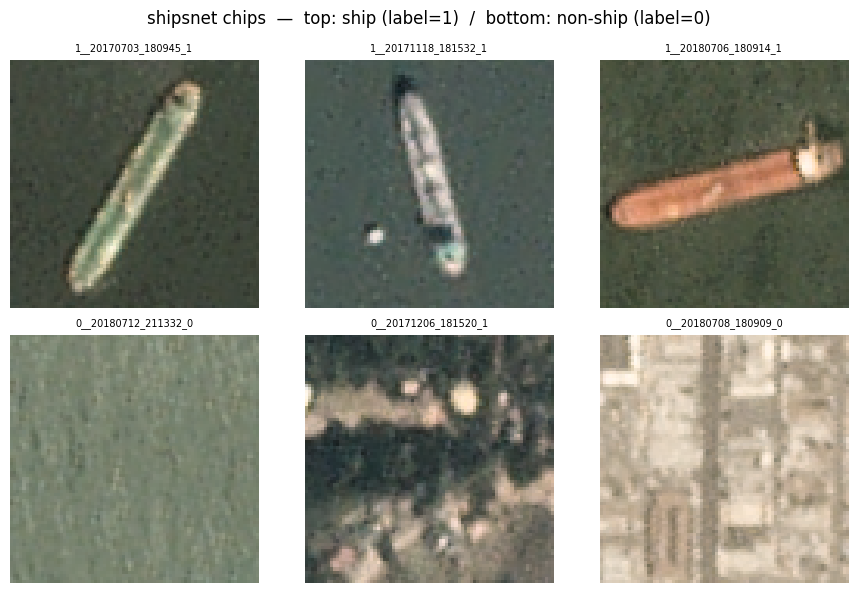


Width  — min: 80, max: 80, mean: 80px
Height — min: 80, max: 80, mean: 80px


In [6]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image

if "SHIPSNET_DIR" not in dir():
    SHIPSNET_DIR = KAGGLE_DIR / "shipsnet" / "shipsnet"
    ship_images = list(SHIPSNET_DIR.glob("1__*.png"))
    nonship_images = list(SHIPSNET_DIR.glob("0__*.png"))

print(f"Ship chips     : {len(ship_images)}")
print(f"Non-ship chips : {len(nonship_images)}")

ship_sample = random.sample(ship_images, min(3, len(ship_images)))
nonship_sample = random.sample(nonship_images, min(3, len(nonship_images)))

fig, axes = plt.subplots(2, 3, figsize=(9, 6))
fig.suptitle("shipsnet chips  —  top: ship (label=1)  /  bottom: non-ship (label=0)", fontsize=12)

for ax, img_path in zip(axes[0], ship_sample):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(img_path.name[:20], fontsize=7)
    ax.axis("off")

for ax, img_path in zip(axes[1], nonship_sample):
    ax.imshow(mpimg.imread(img_path))
    ax.set_title(img_path.name[:20], fontsize=7)
    ax.axis("off")

plt.tight_layout()
plt.show()

size_sample = random.sample(
    ship_images + nonship_images, min(50, len(ship_images) + len(nonship_images))
)
widths, heights = zip(*[Image.open(p).size for p in size_sample])
print(f"\nWidth  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.0f}px")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.0f}px")

---
## Section 2: Image Annotation in Roboflow

The Kaggle dataset has no ship bounding boxes. Annotation must be done in Roboflow before training.

### Steps (done manually on the web)
1. Go to [app.roboflow.com](https://app.roboflow.com) → New Project → Object Detection
2. Name: `ship-detection-satellite` — Class: `ship`
3. Upload images from the `sea/` folder (200–500 is a good starting point)
4. Annotate ships using the bounding box tool. Use **Auto Label** (Grounding DINO / SAM) to speed up the process
5. Generate dataset: 70/20/10 train/valid/test split, enable augmentations (rotate, flip, brightness)
6. Export as **YOLOv11** format

> **Quick alternative:** use a pre-annotated ship dataset from Roboflow Universe
> (search for `ship satellite` at universe.roboflow.com).

In [ ]:
# Optional: upload images programmatically instead of via the web UI
from roboflow import Roboflow
from tqdm import tqdm

WORKSPACE_NAME = "leonardos-workspace-yllzl"
PROJECT_NAME = "ship-4jnj0-ku1a7"

rf = Roboflow(api_key=ROBOFLOW_API_KEY)
project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)

upload_sample = random.sample(ship_images, min(300, len(ship_images)))
print(f"Uploading {len(upload_sample)} images to Roboflow...")

for img_path in tqdm(upload_sample, unit="img"):
    project.upload(str(img_path), batch_name="kaggle-shipsnet-batch-1")

print("Upload complete. Annotate the ships at app.roboflow.com before continuing.")

---
## Section 3: Download Annotated Dataset from Roboflow

Once annotation and dataset generation are done in Roboflow, download it here.

In [7]:
from roboflow import Roboflow

WORKSPACE_NAME = "leonardos-workspace-yllzl"
PROJECT_NAME = "ship-4jnj0-ku1a7"
VERSION_NUMBER = 1

ROBOFLOW_DIR = DATASETS_DIR / "roboflow_annotated"

if (ROBOFLOW_DIR / "data.yaml").exists():
    print(f"Annotated dataset already present at {ROBOFLOW_DIR} — skipping download.")
else:
    print(f"Connecting to Roboflow project '{PROJECT_NAME}'...")
    rf = Roboflow(api_key=ROBOFLOW_API_KEY)
    project = rf.workspace(WORKSPACE_NAME).project(PROJECT_NAME)

    print(f"Downloading version {VERSION_NUMBER} in yolov11 format...")
    project.version(VERSION_NUMBER).download("yolov11", location=str(ROBOFLOW_DIR))
    print("Download complete.")

DATA_YAML = ROBOFLOW_DIR / "data.yaml"
print(f"\nDataset location : {ROBOFLOW_DIR}")
print(f"data.yaml        : {DATA_YAML}")

Annotated dataset already present at c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated — skipping download.

Dataset location : c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated
data.yaml        : c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\data.yaml


In [8]:
print("Dataset statistics:")
print("-" * 40)

for split in ["train", "valid", "test"]:
    img_dir = ROBOFLOW_DIR / split / "images"
    label_dir = ROBOFLOW_DIR / split / "labels"
    if not img_dir.exists():
        continue
    images = list(img_dir.glob("*.jpg")) + list(img_dir.glob("*.png"))
    ann_count = sum(
        len([line for line in p.read_text().splitlines() if line.strip()])
        for p in label_dir.glob("*.txt")
    )
    print(f"  {split:8s}: {len(images):4d} images, {ann_count:5d} ship annotations")

print("-" * 40)

Dataset statistics:
----------------------------------------
  train   : 1535 images,  7488 ship annotations
  valid   :  512 images,  2606 ship annotations
  test    :  512 images,  2768 ship annotations
----------------------------------------


---
## Section 4: Fine-tuning YOLO11

| Parameter | Value | Reason |
|-----------|-------|--------|
| `model`   | yolo11m | Better feature extraction for small objects (ships = ~20px) |
| `epochs`  | 120 | 10 epochs is insufficient for convergence |
| `imgsz`   | 960 | Balanced memory/precision for RTX A4000 |
| `patience` | 50 | Early stopping to prevent overfitting |
| `degrees` | 30 | Satellites capture ships at any angle |
| `flipud`  | 0.5 | No absolute "up" in satellite images |
| `mosaic`  | 1.0 | Significantly improves detection of small objects |

In [9]:
from ultralytics import YOLO
from ultralytics.utils.downloads import safe_download

FORCE_RETRAIN = True  # set to True to start a new experiment ignoring existing runs

existing_runs = sorted(
    (RUNS_DIR / "detect").glob("ship_detection_v1*/weights/best.pt"),
    key=lambda p: p.stat().st_mtime,
)

if existing_runs and not FORCE_RETRAIN:
    BEST_WEIGHTS = existing_runs[-1]
    TRAIN_DIR = BEST_WEIGHTS.parent.parent
    print("Existing training run found — skipping training.")
    print(f"  Run      : {TRAIN_DIR}")
    print(f"  Weights  : {BEST_WEIGHTS}")
    print("\nSet FORCE_RETRAIN = True to start a new experiment.")
else:
    MODEL_PATH = MODELS_DIR / MODEL_NAME
    if not MODEL_PATH.exists():
        print(f"Downloading {MODEL_NAME} to {MODELS_DIR}...")
        safe_download(
            url=f"https://github.com/ultralytics/assets/releases/latest/download/{MODEL_NAME}",
            file=MODEL_PATH,
        )
        print(f"Saved to {MODEL_PATH}")
    else:
        print(f"Model already present at {MODEL_PATH}")

    model = YOLO(str(MODEL_PATH))
    results = model.train(
        data=str(DATA_YAML),
        epochs=120,
        imgsz=960,
        batch=-1,
        patience=50,
        device=device,
        cos_lr=True,
        lrf=0.01,
        weight_decay=0.0005,
        warmup_epochs=3,
        cls=0.5,
        degrees=10.0,
        flipud=0.5,
        fliplr=0.5,
        scale=0.5,
        shear=0.0,
        mosaic=0.5,
        mixup=0.0,
        copy_paste=0.0,
        plots=True,
        name="ship_detection_v3",
        project=str(RUNS_DIR / "detect"),
    )

    TRAIN_DIR = Path(results.save_dir)
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"
    print(f"\nTraining complete. Results saved to: {TRAIN_DIR}")

Model already present at c:\Users\leona\source\repos\diplo-mod-2\models\yolo11m.pt
New https://pypi.org/project/ultralytics/8.4.60 available  Update with 'pip install -U ultralytics'
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
engine\trainer: task=detect, mode=train, model=c:\Users\leona\source\repos\diplo-mod-2\models\yolo11m.pt, data=c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\data.yaml, epochs=120, time=None, patience=50, batch=-1, imgsz=960, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=c:\Users\leona\source\repos\diplo-mod-2\runs\detect, name=ship_detection_v32, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=True, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, s

train: Scanning C:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\train\labels.cache... 1535 images, 0 backgrounds, 0 corrupt: 100%|██████████| 1535/1535 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 14, len(boxes) = 7488. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



val: Scanning C:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\valid\labels.cache... 512 images, 0 backgrounds, 0 corrupt: 100%|██████████| 512/512 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 1, len(boxes) = 2606. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.


...

    120/120      4.01G      1.697      1.345      1.552          3        960: 100%|██████████| 512/512 [01:45<00:00,  4.87it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 86/86 [00:12<00:00,  6.81it/s]

                   all        512       2606      0.727       0.43      0.495      0.255



120 epochs completed in 3.909 hours.
Optimizer stripped from c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v32\weights\last.pt, 40.6MB
Optimizer stripped from c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v32\weights\best.pt, 40.6MB

Validating c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v32\weights\best.pt...
Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 86/86 [00:11<00:00,  7.49it/s]


                   all        512       2606      0.725      0.431      0.494      0.257
Speed: 0.5ms preprocess, 16.3ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v32

Training complete. Results saved to: c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v32


---
## Section 5: Training Results

Training run: c:\Users\leona\source\repos\diplo-mod-2\runs\detect\ship_detection_v32

confusion_matrix_normalized.png


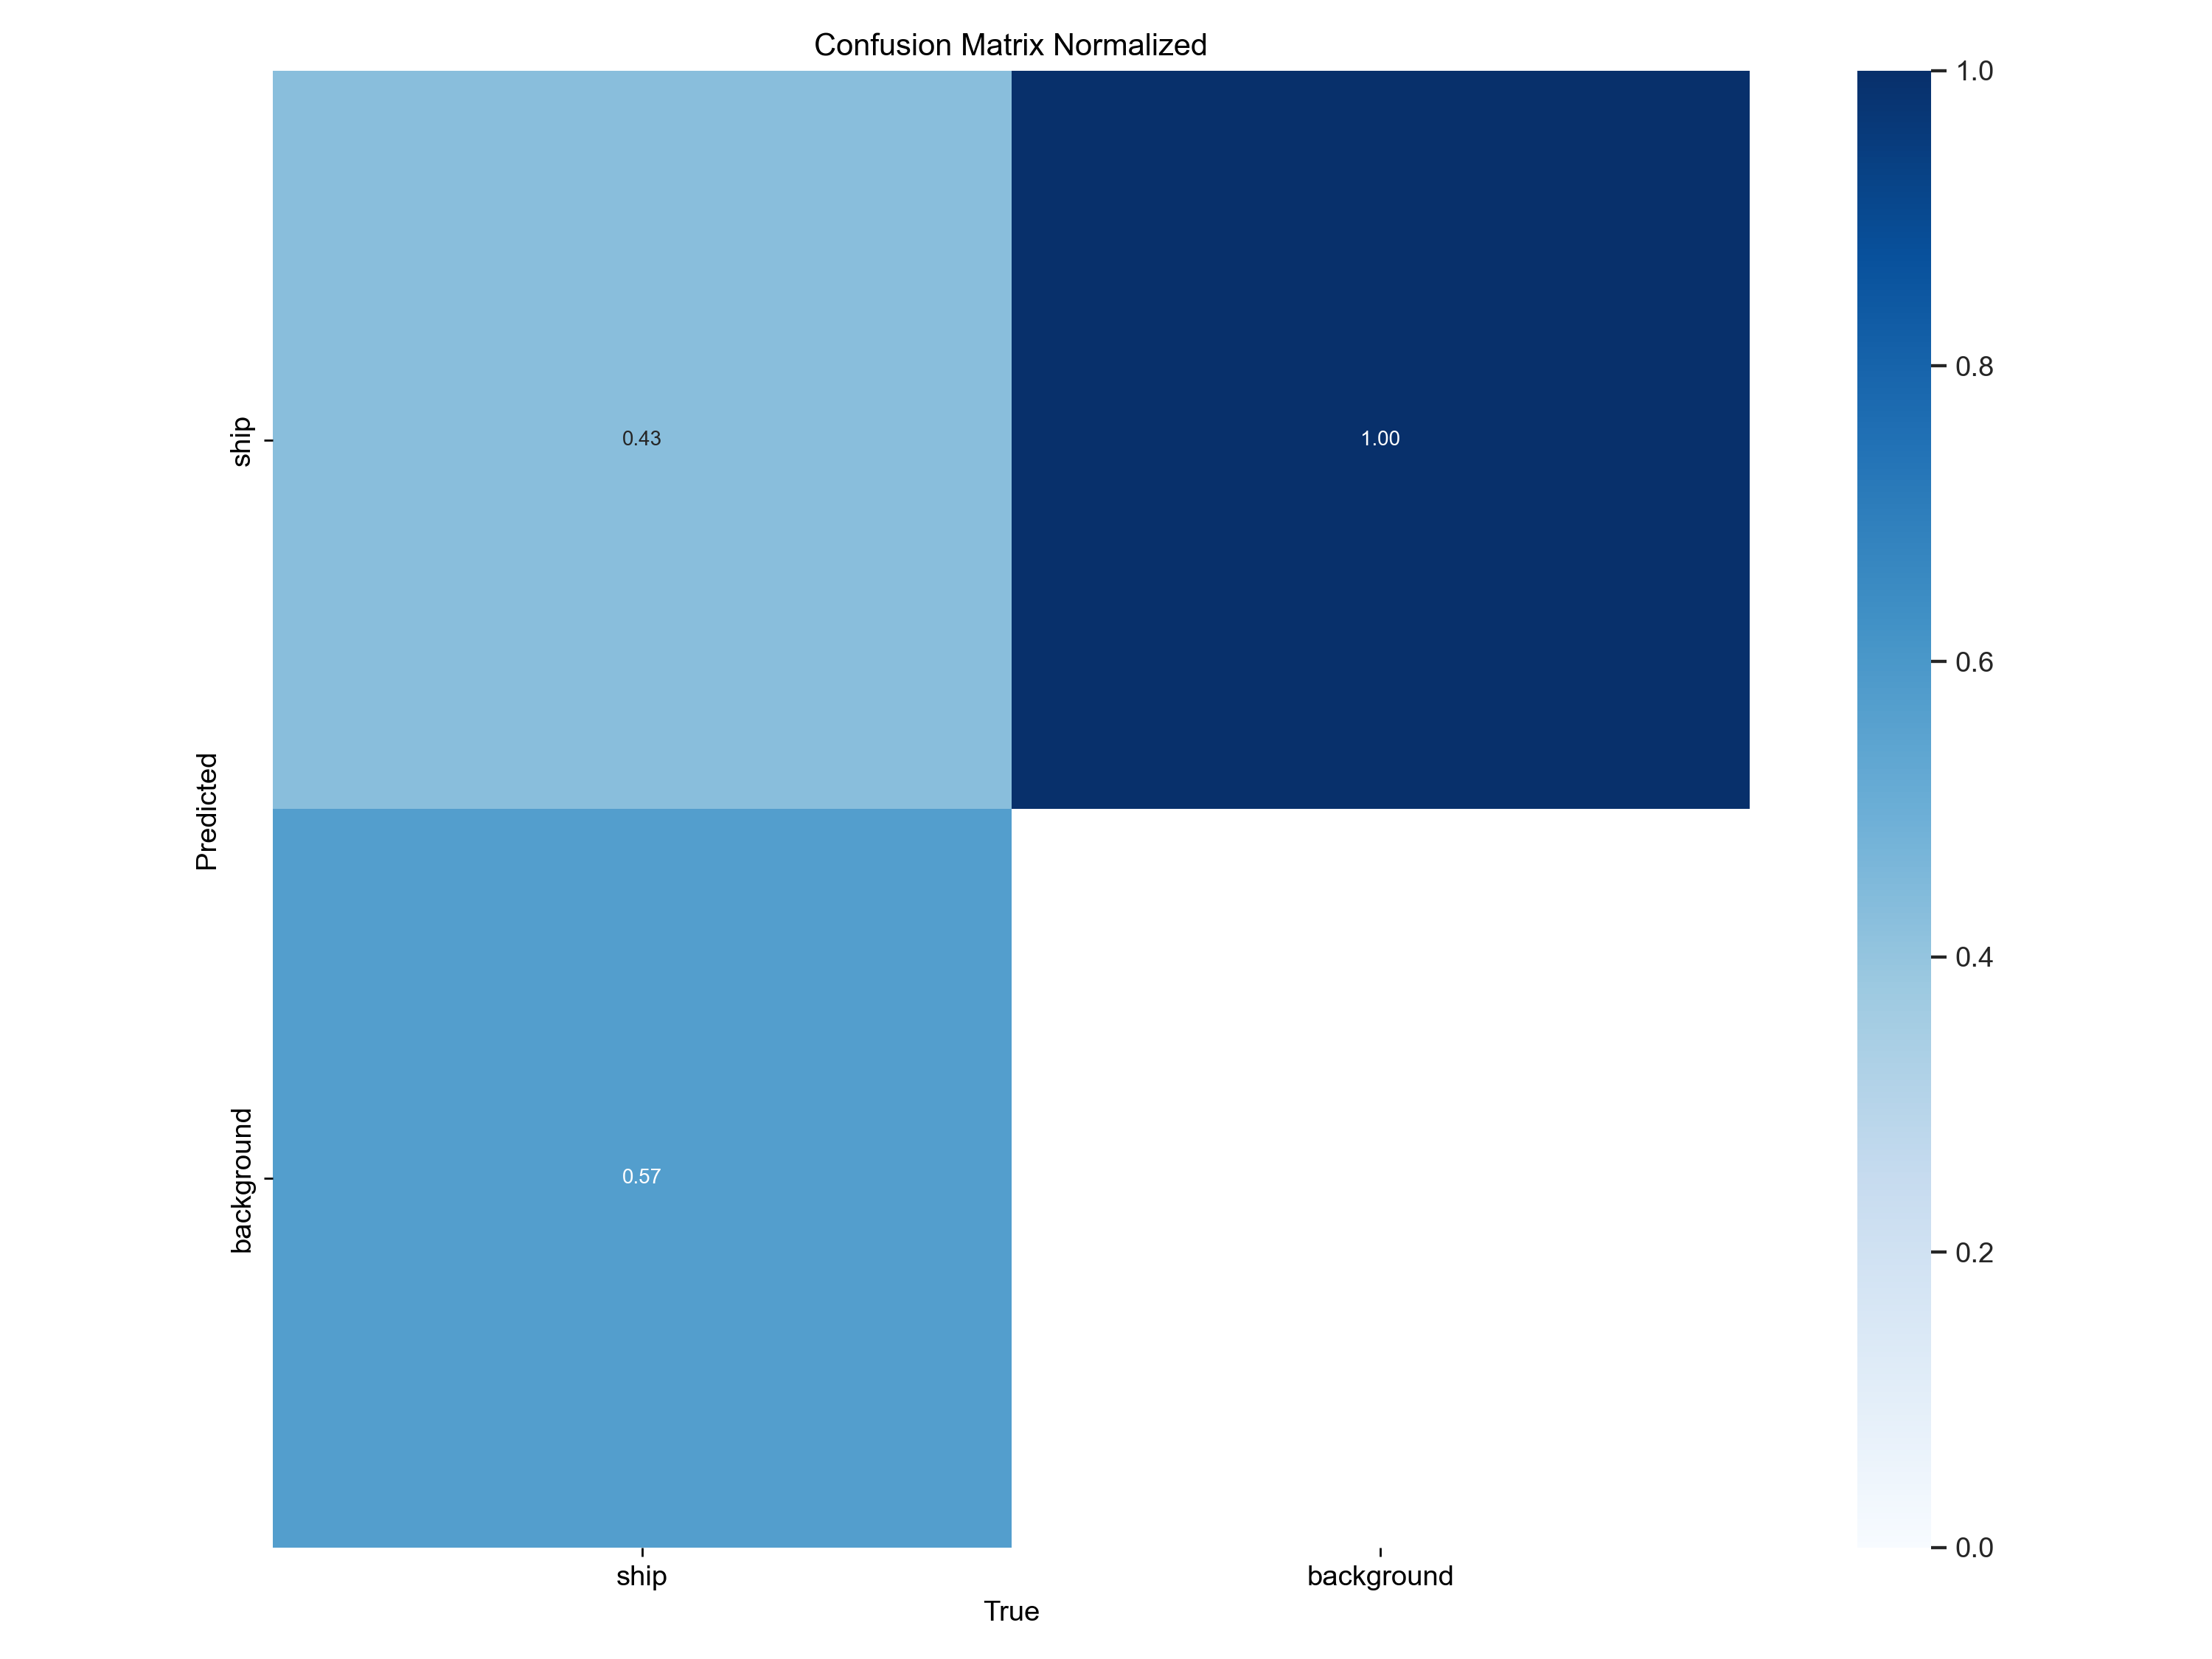


results.png


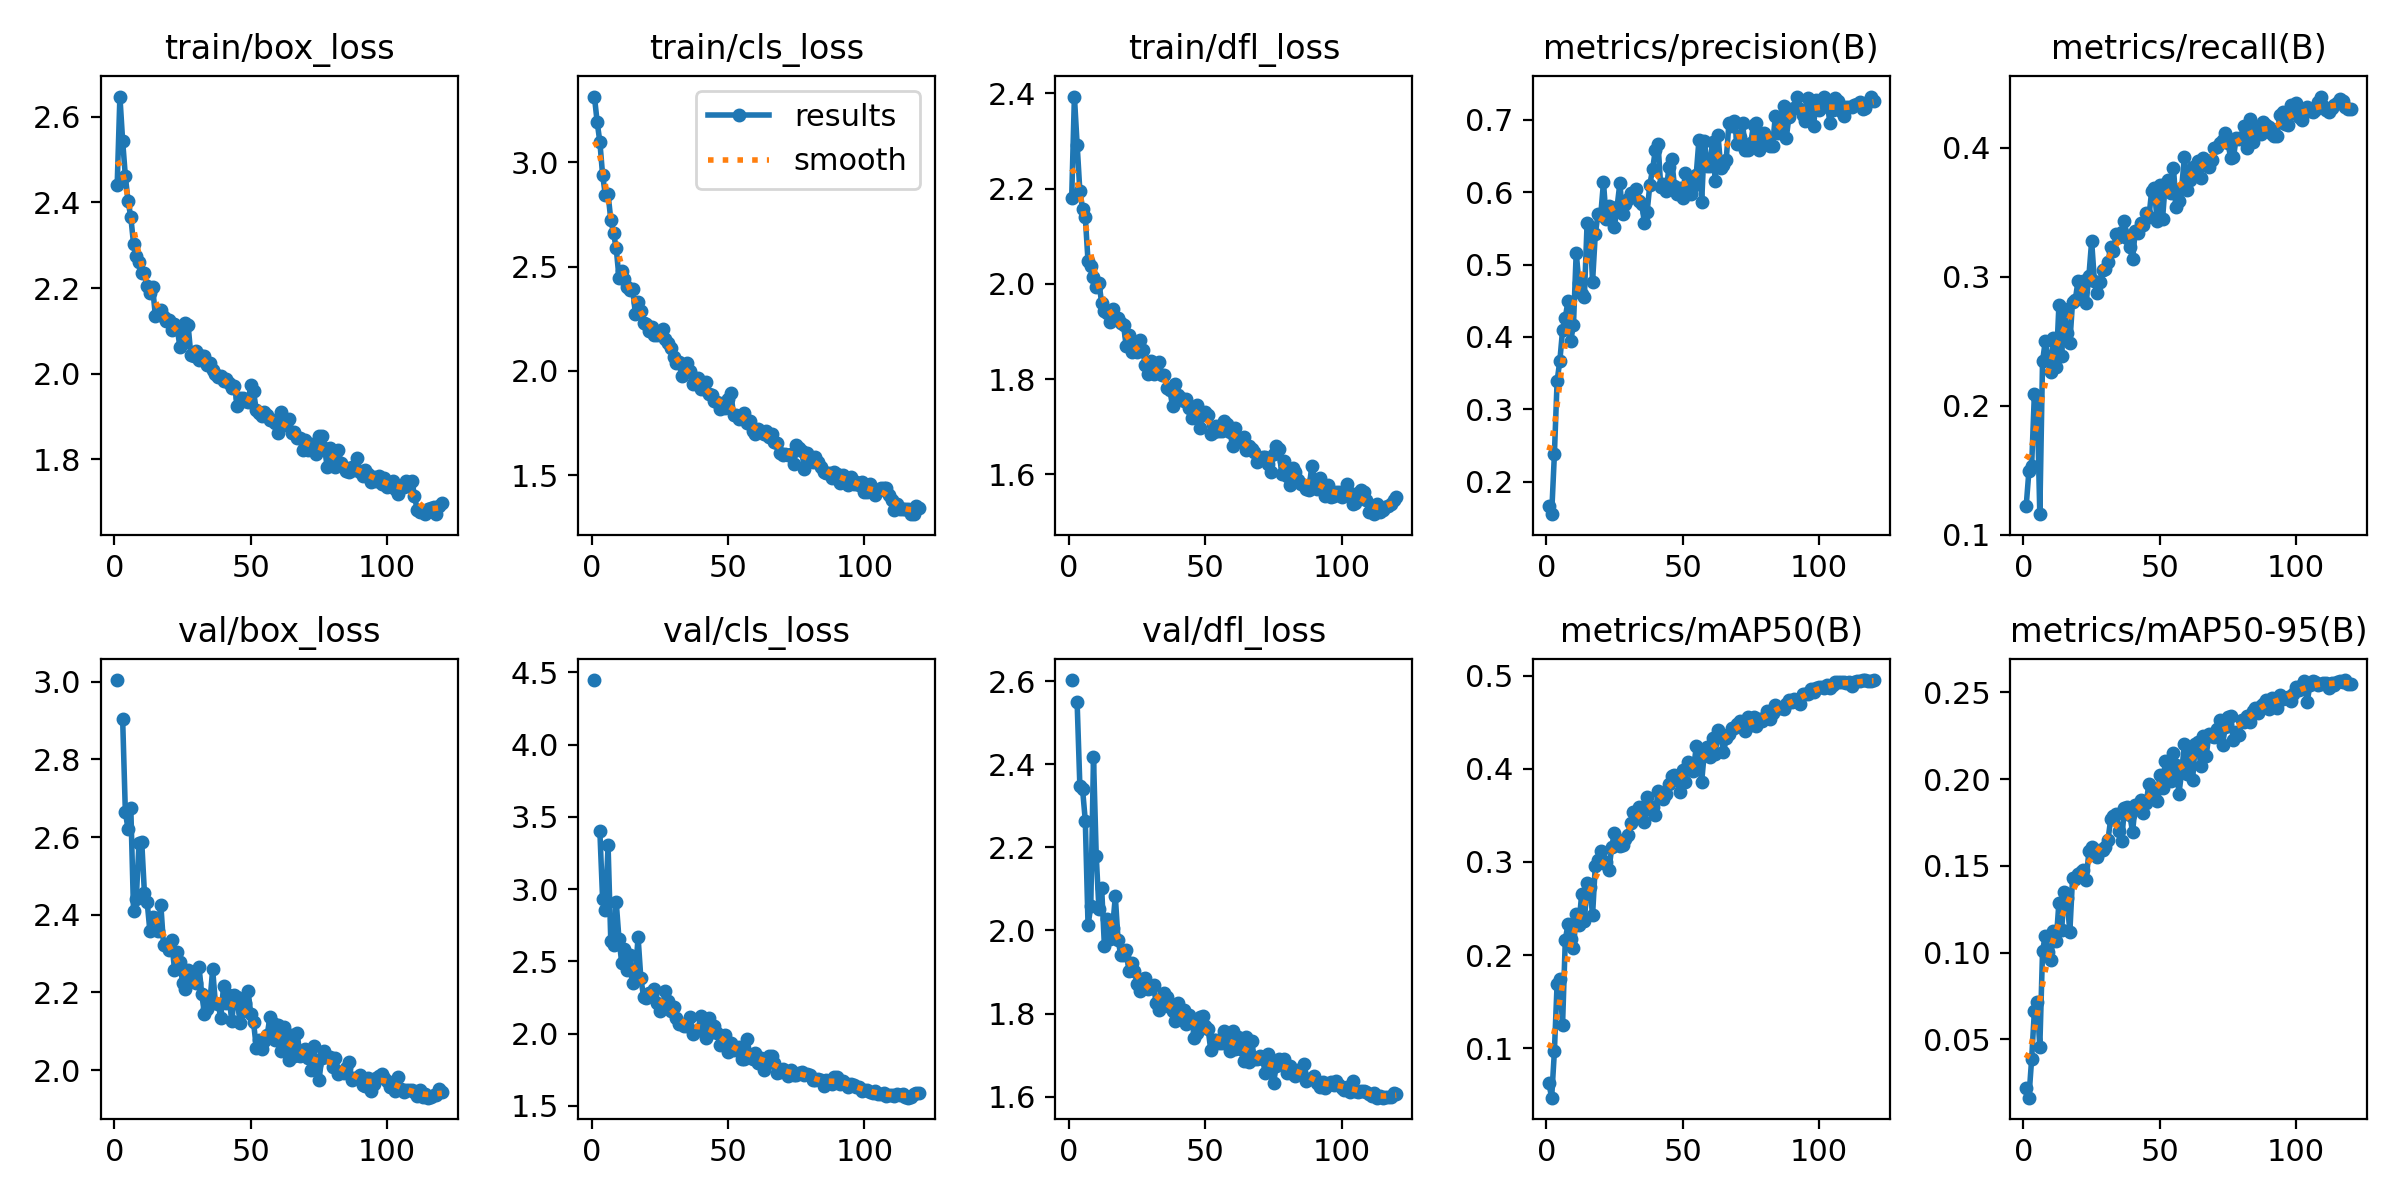


val_batch0_pred.jpg


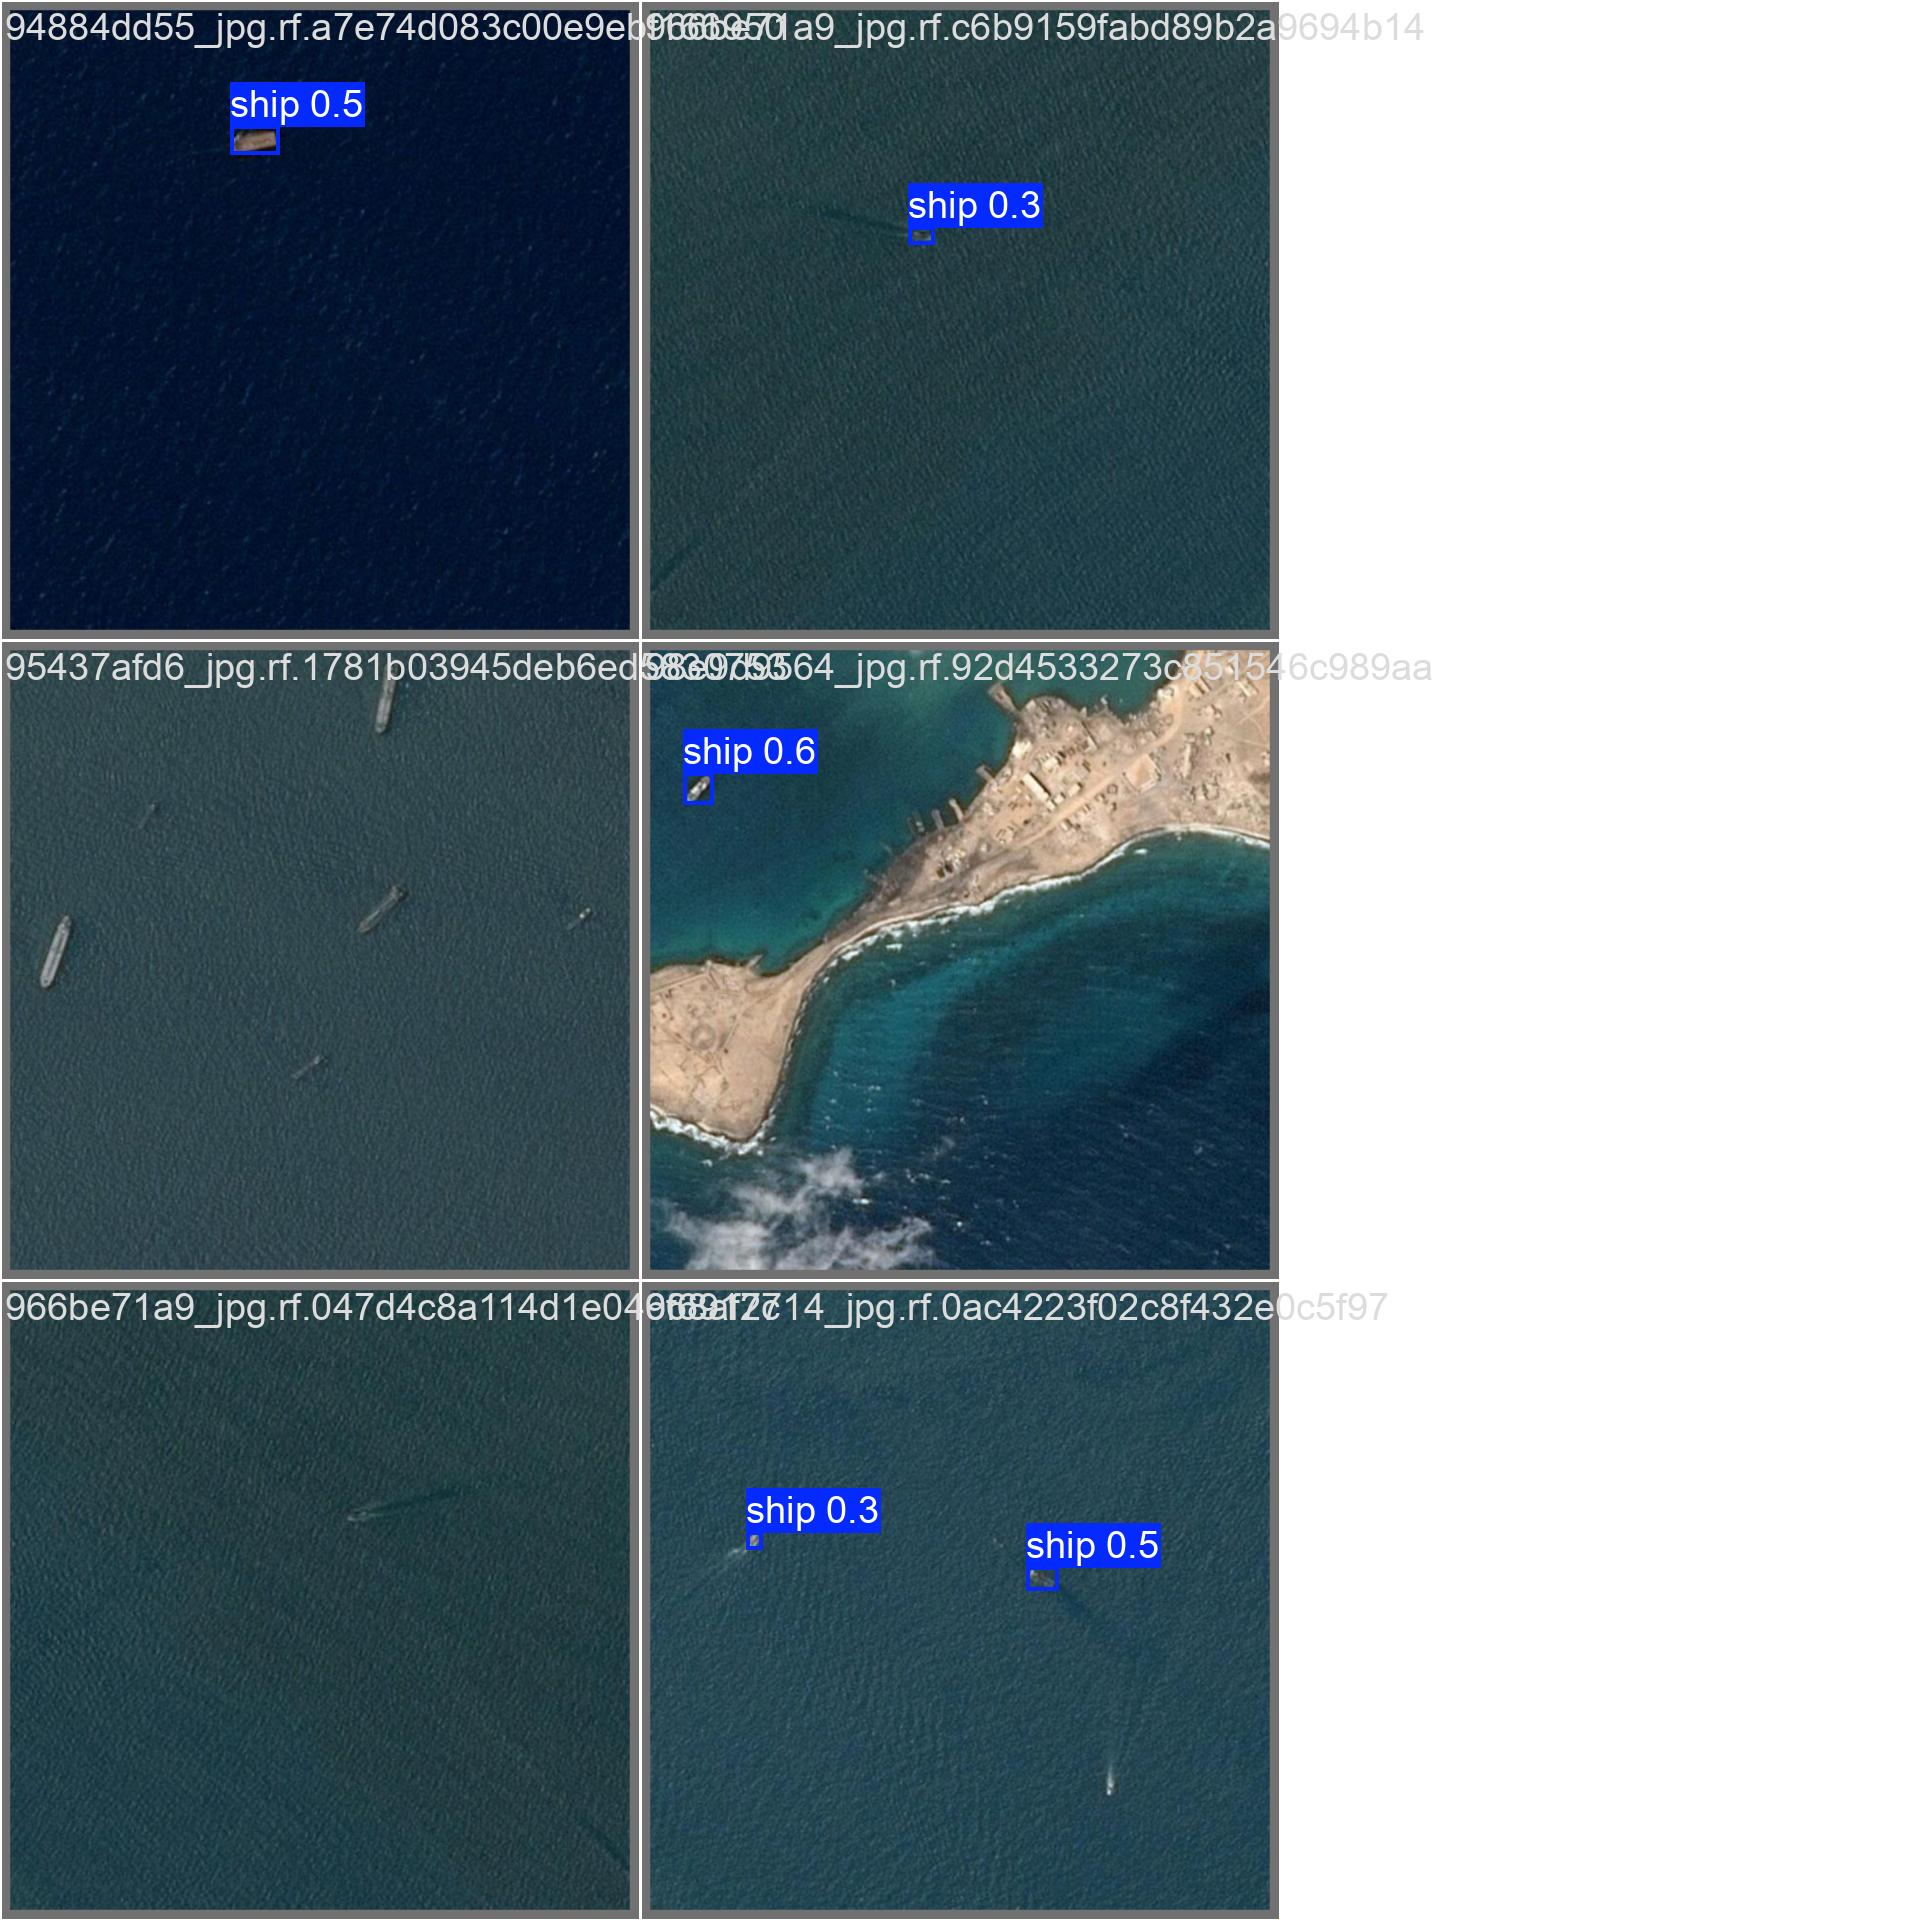

In [10]:
# Resolve latest training run if TRAIN_DIR is not set (re-running this cell after restart)
if "TRAIN_DIR" not in dir() or not Path(TRAIN_DIR).exists():
    train_dirs = sorted(
        RUNS_DIR.glob("detect/ship_detection_v32/"), key=lambda p: p.stat().st_mtime
    )
    TRAIN_DIR = train_dirs[-1]
    BEST_WEIGHTS = TRAIN_DIR / "weights" / "best.pt"

print(f"Training run: {TRAIN_DIR}")

for filename in ["confusion_matrix_normalized.png", "results.png", "val_batch0_pred.jpg"]:
    path = TRAIN_DIR / filename
    if path.exists():
        print(f"\n{filename}")
        display(IPyImage(filename=str(path), width=800))

Training metrics summary:
  Best epoch       : 116
  mAP@50           : 0.4953
  mAP@50-95        : 0.2566
  Precision        : 0.7150
  Recall           : 0.4378


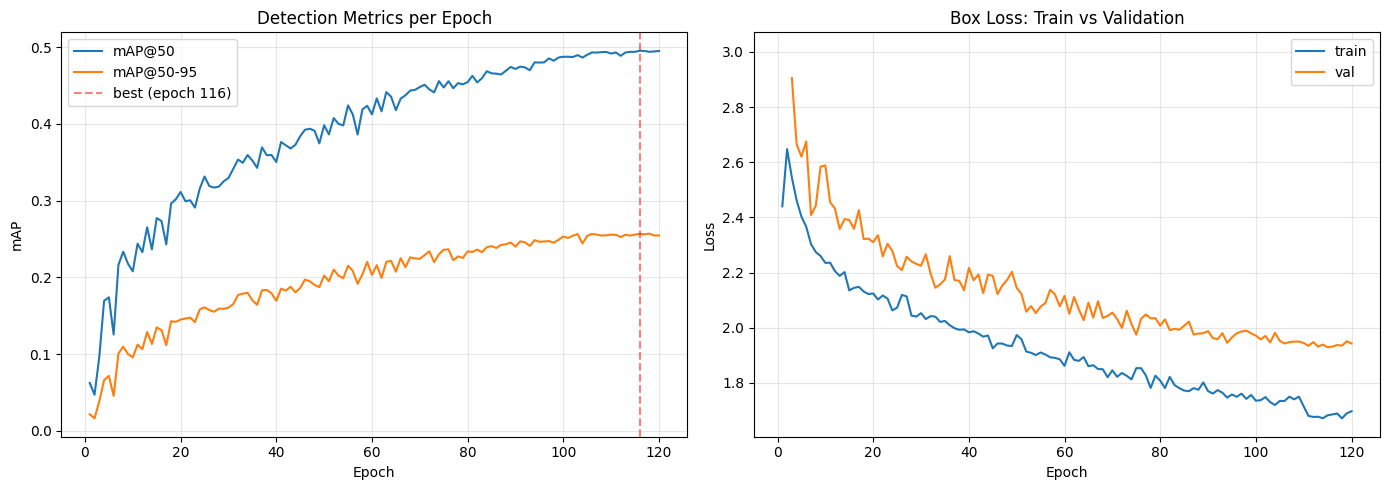

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

results_csv = TRAIN_DIR / "results.csv"
df = pd.read_csv(results_csv)
df.columns = df.columns.str.strip()

best_epoch = df["metrics/mAP50(B)"].idxmax()
best = df.iloc[best_epoch]

print("Training metrics summary:")
print(f"  Best epoch       : {best_epoch + 1}")
print(f"  mAP@50           : {best.get('metrics/mAP50(B)', 0):.4f}")
print(f"  mAP@50-95        : {best.get('metrics/mAP50-95(B)', 0):.4f}")
print(f"  Precision        : {best.get('metrics/precision(B)', 0):.4f}")
print(f"  Recall           : {best.get('metrics/recall(B)', 0):.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df.index + 1, df["metrics/mAP50(B)"], label="mAP@50")
ax1.plot(df.index + 1, df["metrics/mAP50-95(B)"], label="mAP@50-95")
ax1.axvline(
    best_epoch + 1, color="red", linestyle="--", alpha=0.5, label=f"best (epoch {best_epoch + 1})"
)
ax1.set(title="Detection Metrics per Epoch", xlabel="Epoch", ylabel="mAP")
ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(df.index + 1, df["train/box_loss"], label="train")
ax2.plot(df.index + 1, df["val/box_loss"], label="val")
ax2.set(title="Box Loss: Train vs Validation", xlabel="Epoch", ylabel="Loss")
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6: Validation

Evaluate the model on the **test set** — data the model never saw during training.

Target metrics for a usable ship detector:
- **mAP@50 > 0.70** — good overall detection quality
- **Recall > Precision** — for maritime monitoring, missing a ship (false negative) is worse than a false alarm

In [12]:
from ultralytics import YOLO

val_model = YOLO(str(BEST_WEIGHTS))
val_results = val_model.val(
    data=str(DATA_YAML),
    split="test",
    conf=0.10,  # lower threshold prioritises recall over precision
    iou=0.5,
)

print(f"\nmAP@50    : {val_results.box.map50:.4f}")
print(f"mAP@50-95 : {val_results.box.map:.4f}")
print(f"Precision : {val_results.box.mp:.4f}")
print(f"Recall    : {val_results.box.mr:.4f}")

Ultralytics 8.3.23  Python-3.10.11 torch-2.6.0+cu124 CUDA:0 (NVIDIA RTX A4000 Laptop GPU, 8192MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs


val: Scanning C:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\labels.cache... 512 images, 0 backgrounds, 0 corrupt: 100%|██████████| 512/512 [00:00<?, ?it/s]

WARNING  Box and segment counts should be equal, but got len(segments) = 7, len(boxes) = 2768. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.



                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 32/32 [00:16<00:00,  1.89it/s]


                   all        512       2768      0.748      0.469      0.611      0.333
Speed: 0.7ms preprocess, 25.8ms inference, 0.0ms loss, 1.5ms postprocess per image
Results saved to C:\Users\leona\source\repos\diplo-mod-2\runs\detect\val5

mAP@50    : 0.6112
mAP@50-95 : 0.3333
Precision : 0.7484
Recall    : 0.4693


---
## Section 7: Inference with the Fine-tuned Model

In [15]:
from ultralytics import YOLO

test_images_dir = ROBOFLOW_DIR / "test" / "images"
inf_model = YOLO(str(BEST_WEIGHTS))

inf_results = inf_model.predict(
    source=str(test_images_dir),
    conf=0.20,
    iou=0.45,
    save=True,
    name="ship_detection_test",
    project=str(RUNS_DIR / "detect"),
)

predict_dirs = sorted(
    RUNS_DIR.glob("detect/ship_detection_test*/"), key=lambda p: p.stat().st_mtime
)
latest_predict = predict_dirs[-1]
print(f"Predictions saved to: {latest_predict}")


image 1/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\0150b2c24_jpg.rf.7f45d612069a712643ea16a20a5ed840.jpg: 960x960 (no detections), 84.3ms
image 2/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.09bb8db398c9799c6ad73c43d0cf5ce0.jpg: 960x960 1 ship, 24.5ms
image 3/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.99bd39aed3fef732f1be4c1c17da5270.jpg: 960x960 1 ship, 23.2ms
image 4/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\042c8028f_jpg.rf.b25229bd9f4e0ee92fa515edd146529a.jpg: 960x960 1 ship, 24.0ms
image 5/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\04e7626b1_jpg.rf.bc7c76ff2519bc79fd2a3122b62100b1.jpg: 960x960 (no detections), 23.9ms
image 6/512 c:\Users\leona\source\repos\diplo-mod-2\datasets\roboflow_annotated\test\images\056949650_jpg.rf.8bf859c61ffed88571ec88

Showing 6 sample predictions:


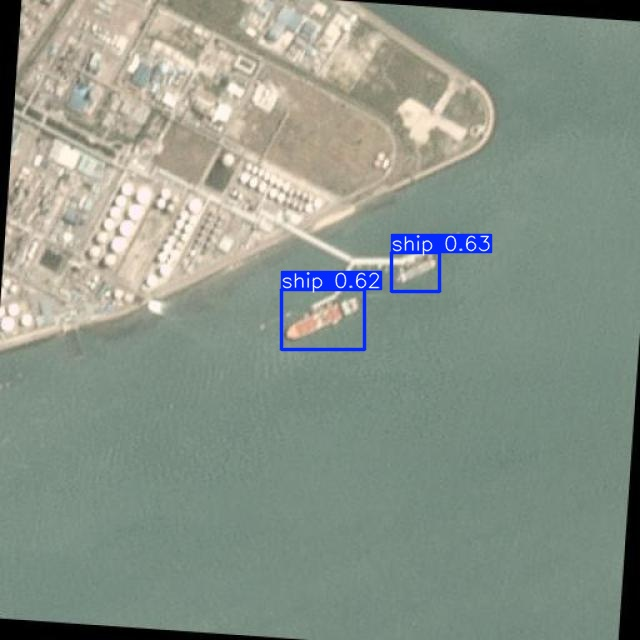

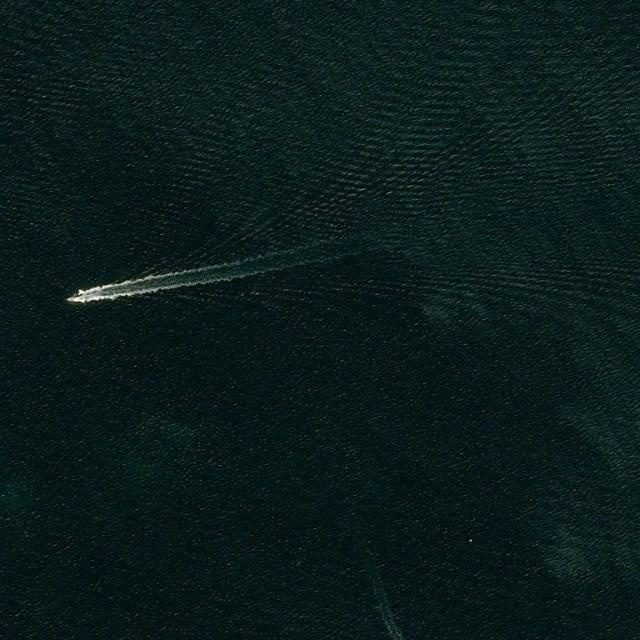

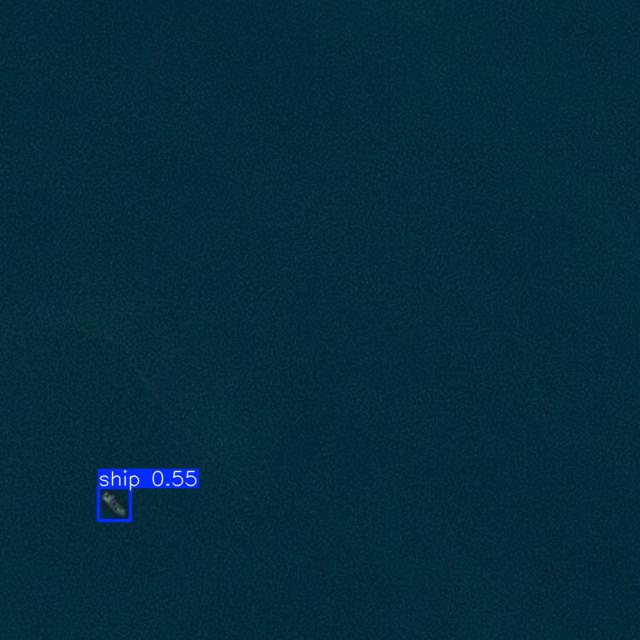

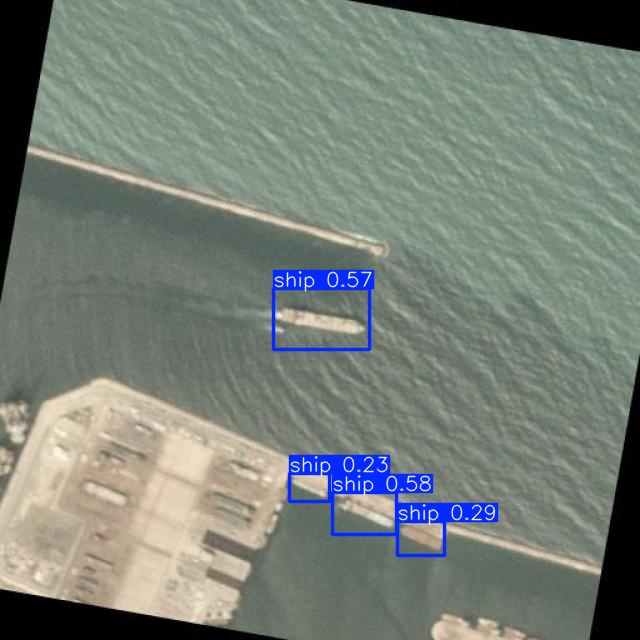

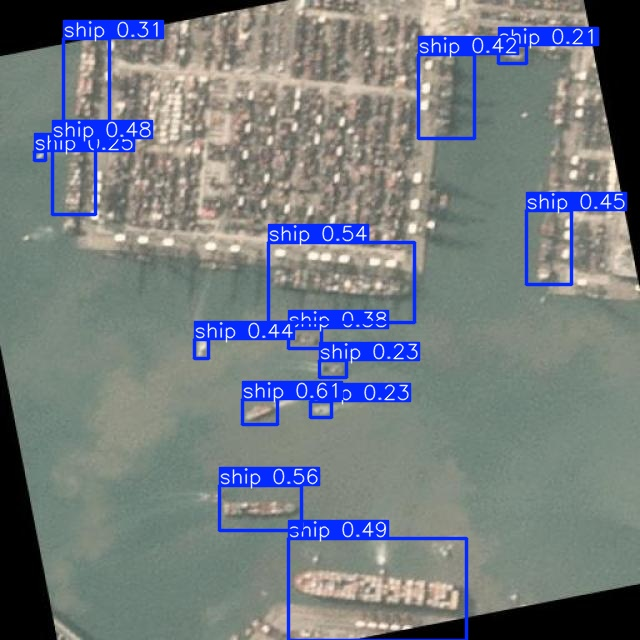

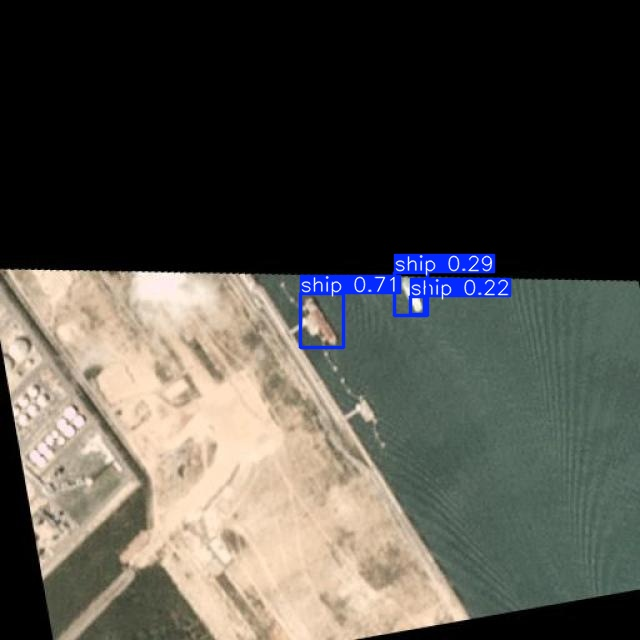

In [16]:
result_images = list(latest_predict.glob("*.jpg")) + list(latest_predict.glob("*.png"))
sample = random.sample(result_images, min(6, len(result_images)))

print(f"Showing {len(sample)} sample predictions:")
for img_path in sample:
    display(IPyImage(filename=str(img_path), width=700))
    print()


0: 960x960 13 ships, 237.2ms
Speed: 17.5ms preprocess, 237.2ms inference, 1.1ms postprocess per image at shape (1, 3, 960, 960)
Image : 20190124_023316_101e_3B_Visual_3_png_jpg.rf.a60cbff36b1321de0455041f92885f37.jpg
Ships detected: 13
  Ship 1: bbox=(0,229,95,398)  size=95x169px  conf=0.67
  Ship 2: bbox=(235,225,256,261)  size=21x36px  conf=0.65
  Ship 3: bbox=(307,534,379,579)  size=73x45px  conf=0.63
  Ship 4: bbox=(474,468,555,522)  size=81x54px  conf=0.62
  Ship 5: bbox=(307,280,401,421)  size=94x142px  conf=0.61
  Ship 6: bbox=(124,179,180,261)  size=56x83px  conf=0.54
  Ship 7: bbox=(295,285,319,319)  size=24x33px  conf=0.50
  Ship 8: bbox=(260,310,281,337)  size=21x27px  conf=0.42
  Ship 9: bbox=(568,120,639,170)  size=72x50px  conf=0.39
  Ship 10: bbox=(227,290,242,313)  size=15x22px  conf=0.38
  Ship 11: bbox=(312,192,329,206)  size=17x14px  conf=0.31
  Ship 12: bbox=(58,376,84,404)  size=26x28px  conf=0.29
  Ship 13: bbox=(456,81,554,136)  size=98x55px  conf=0.27


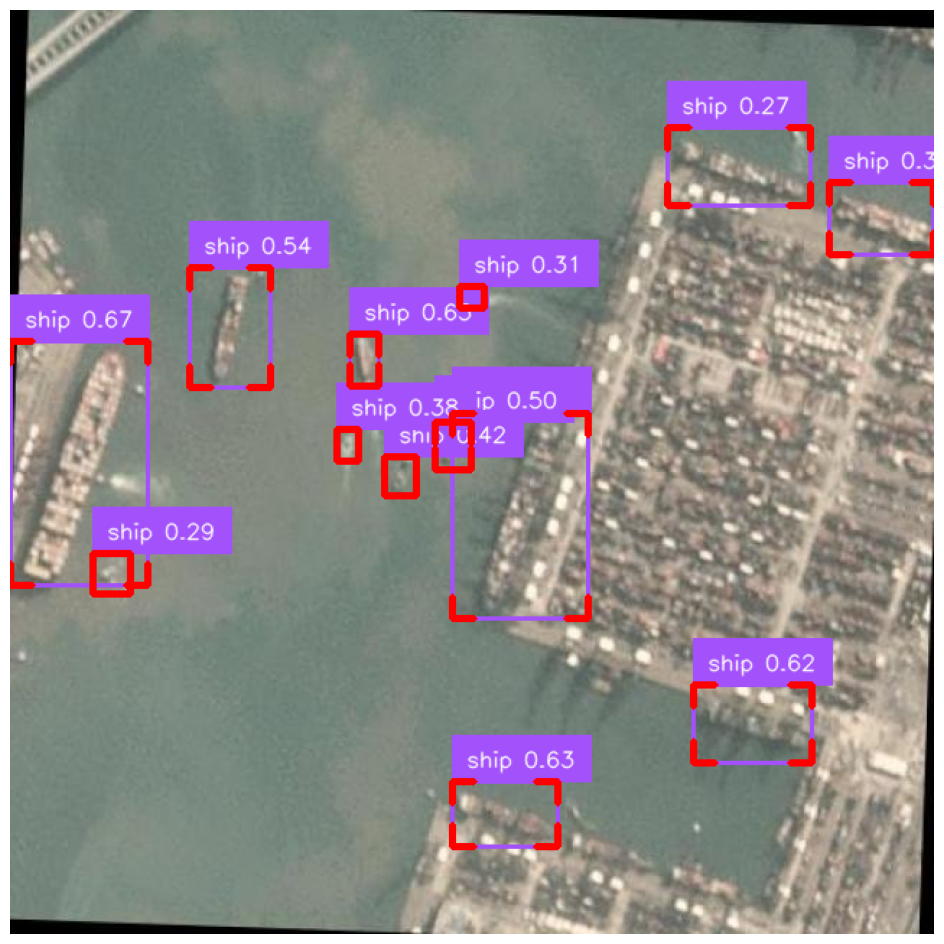

In [17]:
# Programmatic inference with supervision for richer visualisation
import supervision as sv

test_images = list(test_images_dir.glob("*.jpg")) + list(test_images_dir.glob("*.png"))
img_path = random.choice(test_images)
image = Image.open(img_path).convert("RGB")

result = inf_model.predict(image, conf=0.25, iou=0.45)[0]
detections = sv.Detections.from_ultralytics(result)

print(f"Image : {img_path.name}")
print(f"Ships detected: {len(detections)}")
assert detections.confidence is not None
for i, (box, conf) in enumerate(zip(detections.xyxy, detections.confidence), start=1):
    x1, y1, x2, y2 = box
    print(
        f"  Ship {i}: bbox=({x1:.0f},{y1:.0f},{x2:.0f},{y2:.0f})  "
        f"size={x2 - x1:.0f}x{y2 - y1:.0f}px  conf={conf:.2f}"
    )

labels = [f"ship {c:.2f}" for c in detections.confidence]
annotated = image.copy()
annotated = sv.BoxAnnotator(thickness=2).annotate(annotated, detections)
annotated = sv.LabelAnnotator(text_color=sv.Color.WHITE, text_scale=0.5).annotate(
    annotated, detections, labels
)
annotated = sv.BoxCornerAnnotator(color=sv.Color.RED).annotate(annotated, detections)
sv.plot_image(annotated, size=(12, 12))

---
## Section 8: Confidence Threshold Analysis

- **Low conf (0.10–0.20):** more detections, more false positives
- **High conf (0.50–0.70):** higher precision, may miss small ships

For maritime surveillance, **recall is prioritised** — missing a ship is worse than a false alarm.
Recommended range: **0.25–0.40**.

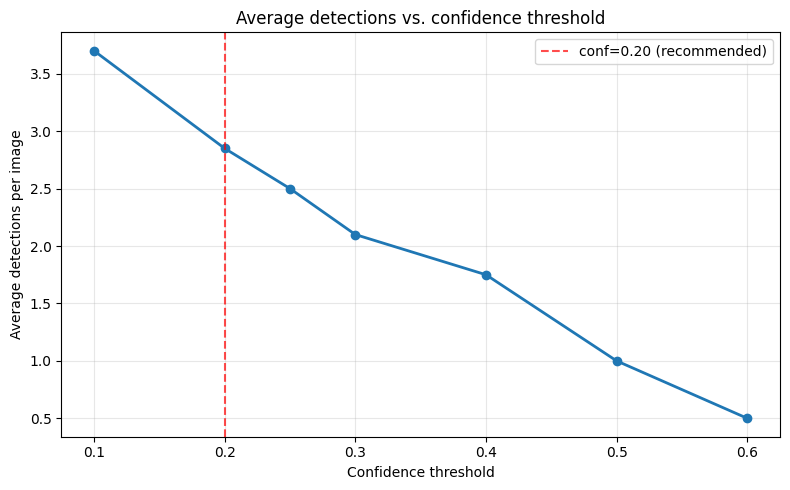

In [18]:
sweep_sample = random.sample(test_images, min(20, len(test_images)))
conf_values = [0.10, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]
avg_detections = []

for conf in conf_values:
    total = sum(
        len(inf_model.predict(str(p), conf=conf, verbose=False)[0].boxes) for p in sweep_sample
    )
    avg_detections.append(total / len(sweep_sample))

plt.figure(figsize=(8, 5))
plt.plot(conf_values, avg_detections, marker="o", linewidth=2)
plt.axvline(0.20, color="red", linestyle="--", alpha=0.7, label="conf=0.20 (recommended)")
plt.xlabel("Confidence threshold")
plt.ylabel("Average detections per image")
plt.title("Average detections vs. confidence threshold")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Next Steps

- **More annotated data** — the single most effective improvement
- **Higher resolution** — try `imgsz=1280` with `batch=8` for small ships
- **SAHI** — sliced inference for very high-resolution satellite images: `pip install sahi`
- **ONNX export** — CPU inference without PyTorch: `model.export(format='onnx')`
- **TensorRT export** — optimised NVIDIA inference: `model.export(format='engine')`
- **Multi-class extension** — add `cargo_ship`, `tanker`, `sailboat` classes with more annotations

**References:**
- [Ultralytics YOLO11 Docs](https://docs.ultralytics.com)
- [Roboflow Universe — ship datasets](https://universe.roboflow.com/search?q=ship+satellite)
- [SAHI for small objects](https://github.com/obss/sahi)